# 😴 Sleep Stage Classification — Exploratory Data Analysis

Kaggle competition **"inception"** (YDL 2026). The goal is to predict `sleep_stage`
(4 classes: 0, 1, 2, 3) for each ~30-second epoch of a sleep recording.

This notebook is **EDA only** — we look at the data before modelling:
shapes, dtypes, missing values, the target distribution, feature distributions,
correlations, and how each feature separates the sleep stages.

**Feature groups (medical meaning):**
- **EEG** (brain waves): `delta`/`slow_osc` = deep sleep, `alpha` = relaxed wake,
  `sigma`/`spindle`/`kcomplex` = stage 2, `beta`/`gamma` = alert wake,
  `spectral_entropy` = how mixed the rhythm is (high = awake).
- **EMG** (muscle): chin tone — high awake, lowest in REM.
- **EOG** (eyes): movement/amplitude/burst — high in REM. `eog_burst_index` is ~50% missing.
- **Cardio/respiratory**: heart rate, HRV, respiration, SpO2, body movement.

## 0. Imports & display settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)

pandas 2.3.3 | numpy 2.3.5 | seaborn 0.13.2


## 1. Load the data
The CSVs live in the `inception/` subfolder.

In [2]:
DATA_DIR = "inception"   # data files live in the inception/ subfolder

train = pd.read_csv(f"{DATA_DIR}/train.csv")
test  = pd.read_csv(f"{DATA_DIR}/test.csv")
sample_submission = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

TARGET   = "sleep_stage"
ID_COL   = "id"
FEATURES = [c for c in train.columns if c not in (ID_COL, TARGET)]

print(f"train shape: {train.shape}")
print(f"test  shape: {test.shape}")
print(f"submission shape: {sample_submission.shape}")
print(f"\n{len(FEATURES)} feature columns:")
print(FEATURES)

train shape: (9000, 23)
test  shape: (5000, 22)
submission shape: (5000, 2)

21 feature columns:
['eeg_delta_power', 'eeg_theta_power', 'eeg_alpha_power', 'eeg_sigma_power', 'eeg_beta_power', 'eeg_gamma_power', 'eeg_slow_osc_power', 'eeg_spectral_entropy', 'eeg_spindle_density', 'eeg_kcomplex_rate', 'emg_chin_tone', 'emg_tone_variance', 'eog_movement_density', 'eog_amplitude', 'heart_rate_mean', 'heart_rate_variability', 'respiration_rate', 'respiration_variability', 'spo2_mean', 'body_movement_index', 'eog_burst_index']


## 2. First look at the rows

In [3]:
train.head()

,id,eeg_delta_power,eeg_theta_power,eeg_alpha_power,eeg_sigma_power,eeg_beta_power,eeg_gamma_power,eeg_slow_osc_power,eeg_spectral_entropy,eeg_spindle_density,eeg_kcomplex_rate,emg_chin_tone,emg_tone_variance,eog_movement_density,eog_amplitude,heart_rate_mean,heart_rate_variability,respiration_rate,respiration_variability,spo2_mean,body_movement_index,eog_burst_index,sleep_stage
0,0,-1.51474,1.40728,10.33510,-1.61350,3.73081,0.99850,1.85689,-3.24253,-1.27096,-1.66370,2.79720,-1.76807,2.65567,1.98733,1.60184,-2.49794,-0.59521,1.71154,1.93342,1.57365,-1.36230,1
1,1,-0.28998,0.89706,1.62494,2.41580,-2.70265,-0.10131,-1.68955,0.01442,-2.87943,-0.03516,0.66264,-0.35469,4.36423,0.09942,3.38567,-0.56386,2.16016,-4.32301,1.07270,-2.43903,-0.37271,2
2,2,3.35435,0.32987,-5.41547,2.38680,-2.90584,-2.93372,-3.11713,-0.04647,1.61782,-0.53028,-2.08711,1.49050,-3.87561,-0.87681,-2.84480,5.08383,-4.60411,0.37967,-2.06913,2.67324,NaN,3
3,3,-1.44917,-0.04374,1.71560,-1.27770,-0.19007,2.21826,1.69621,0.39756,0.00534,-0.65535,0.98192,1.12176,1.41415,0.39275,0.55060,-2.12910,2.32790,0.78319,0.98233,1.53824,-0.25040,1
4,4,1.35898,-2.36720,-7.40779,5.31815,-2.55954,-5.13284,-5.26634,1.73985,1.04618,-1.04615,-2.74524,-0.31044,-0.55616,0.86588,-1.96343,4.30036,0.22130,-1.44020,1.35760,-3.07701,-1.04947,3


In [4]:
test.head()

,id,eeg_delta_power,eeg_theta_power,eeg_alpha_power,eeg_sigma_power,eeg_beta_power,eeg_gamma_power,eeg_slow_osc_power,eeg_spectral_entropy,eeg_spindle_density,eeg_kcomplex_rate,emg_chin_tone,emg_tone_variance,eog_movement_density,eog_amplitude,heart_rate_mean,heart_rate_variability,respiration_rate,respiration_variability,spo2_mean,body_movement_index,eog_burst_index
0,9000,4.24709,2.24352,0.82429,-2.17291,1.43316,-2.25920,1.06346,-1.45614,2.30776,-1.92589,0.47695,-0.01680,-4.50347,-1.21023,-2.24473,2.58896,-5.02117,1.77028,-0.62667,3.20780,-0.14174
1,9001,-2.37302,-5.60293,-3.69060,3.60306,1.18660,-3.03282,-4.45284,0.75015,-1.12286,0.29501,-4.23371,-1.93622,-0.98139,-2.24492,-0.91085,-0.86407,5.24594,-0.40843,2.94304,-3.56779,-0.51467
2,9002,-2.82645,3.41445,2.83025,-0.10690,2.96436,2.80361,-1.56655,-2.70384,2.51496,2.24417,1.76296,-1.40091,-0.00776,4.46619,1.81697,-0.41014,0.33340,4.12864,-1.09006,-2.27858,NaN
3,9003,0.36455,-2.23034,-7.35006,2.78573,-2.35427,-3.43257,-1.45572,3.87522,0.31208,0.18739,-3.80453,-0.23742,-2.65285,-2.54412,-1.82521,0.81569,2.25889,-1.27536,0.49894,-2.48382,0.42914
4,9004,0.36140,-0.27564,5.62351,1.37929,-1.27907,-1.43678,0.11626,-2.40858,-3.44948,-4.30699,1.34741,-1.71887,4.85418,-1.04809,3.73200,-0.28232,-0.04884,-3.16412,2.44813,-0.43193,-0.62831


In [5]:
sample_submission.head()

,id,sleep_stage
0,9000,1
1,9001,1
2,9002,1
3,9003,1
4,9004,1


## 3. Column types & structure
`info()` shows dtypes and the **non-null count** per column — the first hint of missing data.

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       9000 non-null   int64  
 1   eeg_delta_power          9000 non-null   float64
 2   eeg_theta_power          9000 non-null   float64
 3   eeg_alpha_power          9000 non-null   float64
 4   eeg_sigma_power          9000 non-null   float64
 5   eeg_beta_power           9000 non-null   float64
 6   eeg_gamma_power          9000 non-null   float64
 7   eeg_slow_osc_power       9000 non-null   float64
 8   eeg_spectral_entropy     9000 non-null   float64
 9   eeg_spindle_density      9000 non-null   float64
 10  eeg_kcomplex_rate        9000 non-null   float64
 11  emg_chin_tone            9000 non-null   float64
 12  emg_tone_variance        9000 non-null   float64
 13  eog_movement_density     9000 non-null   float64
 14  eog_amplitude           

## 4. Summary statistics
The features look **pre-standardised** (centred near 0, both signs). `count` flags missing values.

In [7]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,9000.0,4499.500000,2598.220545,0.00000,2249.750000,4499.500000,6749.250000,8999.00000
eeg_delta_power,9000.0,-0.015335,2.431299,-9.56738,-1.688420,-0.012190,1.622143,8.79757
eeg_theta_power,9000.0,-0.034072,2.408445,-8.27653,-1.649095,-0.019775,1.603865,9.22248
eeg_alpha_power,9000.0,-0.016476,5.042238,-20.63249,-3.465228,0.018740,3.418938,18.86959
eeg_sigma_power,9000.0,0.012123,2.206821,-7.94784,-1.459777,-0.001480,1.512295,9.60340
eeg_beta_power,9000.0,-0.009634,2.882702,-11.45995,-1.962703,0.005230,1.956398,10.02694
eeg_gamma_power,9000.0,-0.010607,2.427740,-9.63780,-1.651817,0.009700,1.634555,8.29614
eeg_slow_osc_power,9000.0,-0.014176,2.801109,-14.12260,-1.873387,0.022685,1.866453,10.36219
eeg_spectral_entropy,9000.0,0.010259,2.753279,-9.30129,-1.858893,-0.028000,1.881628,10.15988
eeg_spindle_density,9000.0,0.006484,2.174239,-8.82819,-1.484435,0.023765,1.479208,8.93749


## 5. Missing values
Which columns have gaps, in both train and test?

In [8]:
missing = pd.DataFrame({
    "train_missing": train.isna().sum(),
    "train_%": (train.isna().mean() * 100).round(1),
})
test_missing = pd.DataFrame({
    "test_missing": test.isna().sum(),
    "test_%": (test.isna().mean() * 100).round(1),
})
missing = missing.join(test_missing)
missing.sort_values("train_missing", ascending=False)

,train_missing,train_%,test_missing,test_%
eog_burst_index,4501,50.0,2477.0,49.5
id,0,0.0,0.0,0.0
emg_tone_variance,0,0.0,0.0,0.0
body_movement_index,0,0.0,0.0,0.0
spo2_mean,0,0.0,0.0,0.0
respiration_variability,0,0.0,0.0,0.0
respiration_rate,0,0.0,0.0,0.0
heart_rate_variability,0,0.0,0.0,0.0
heart_rate_mean,0,0.0,0.0,0.0
eog_amplitude,0,0.0,0.0,0.0


**Expectation:** only `eog_burst_index` is missing (~50% in both train and test).
Everything else is complete.

## 6. Target distribution (`sleep_stage`)
Is the problem balanced? (Affects the baseline accuracy and the metric choice.)

sleep_stage
0    2001
1    2442
2    2237
3    2320
Name: count, dtype: int64

proportions:
sleep_stage
0    0.222
1    0.271
2    0.249
3    0.258
Name: count, dtype: float64


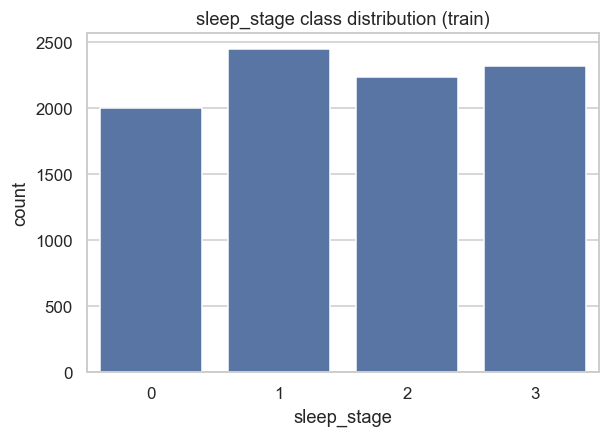

In [9]:
counts = train[TARGET].value_counts().sort_index()
print(counts)
print("\nproportions:")
print((counts / counts.sum()).round(3))

plt.figure(figsize=(6, 4))
sns.countplot(data=train, x=TARGET, order=sorted(train[TARGET].unique()))
plt.title("sleep_stage class distribution (train)")
plt.xlabel("sleep_stage"); plt.ylabel("count")
plt.show()

## 7. Is the missingness informative? ⭐
`eog_burst_index` counts **bursts of rapid eye movement**. In deep sleep the eyes are
still, so there may be *nothing to measure* — meaning the **fact that it's missing**
could itself predict the stage. Let's check before we decide how to fill it.

Sleep-stage distribution within each missingness group (rows = missing flag):
sleep_stage            0      1      2      3
eog_burst_missing                            
0                  0.229  0.273  0.246  0.251
1                  0.216  0.269  0.251  0.264

Fraction missing within each sleep_stage:
             present  missing
sleep_stage                  
0              0.514    0.486
1              0.504    0.496
2              0.496    0.504
3              0.488    0.512


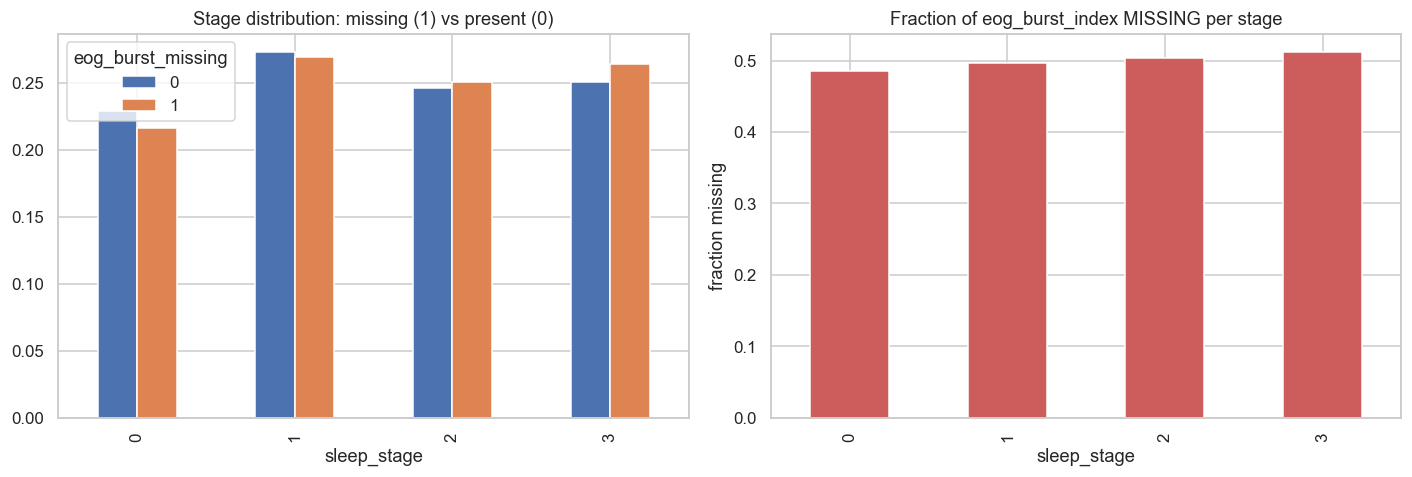

In [10]:
# Flag rows where eog_burst_index is missing
train["eog_burst_missing"] = train["eog_burst_index"].isna().astype(int)

# Within each missingness group, how are the stages distributed?
by_missing = pd.crosstab(train["eog_burst_missing"], train[TARGET], normalize="index").round(3)
print("Sleep-stage distribution within each missingness group (rows = missing flag):")
print(by_missing)

# Reverse view: within each stage, what fraction is missing?
by_stage = pd.crosstab(train[TARGET], train["eog_burst_missing"], normalize="index").round(3)
by_stage.columns = ["present", "missing"]
print("\nFraction missing within each sleep_stage:")
print(by_stage)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
by_missing.T.plot(kind="bar", ax=axes[0])
axes[0].set_title("Stage distribution: missing (1) vs present (0)")
axes[0].set_xlabel("sleep_stage"); axes[0].legend(title="eog_burst_missing")

by_stage["missing"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Fraction of eog_burst_index MISSING per stage")
axes[1].set_xlabel("sleep_stage"); axes[1].set_ylabel("fraction missing")
plt.tight_layout()
plt.show()

**How to read this:** if the bars differ a lot between stages, missingness is
*informative* → keep a `eog_burst_missing` flag column when modelling.
If they're roughly flat, the value is missing at random → a simple median fill is enough.

## 8. Feature distributions (histograms)
Shapes, spread, and any skew/outliers. (NaNs are dropped automatically.)

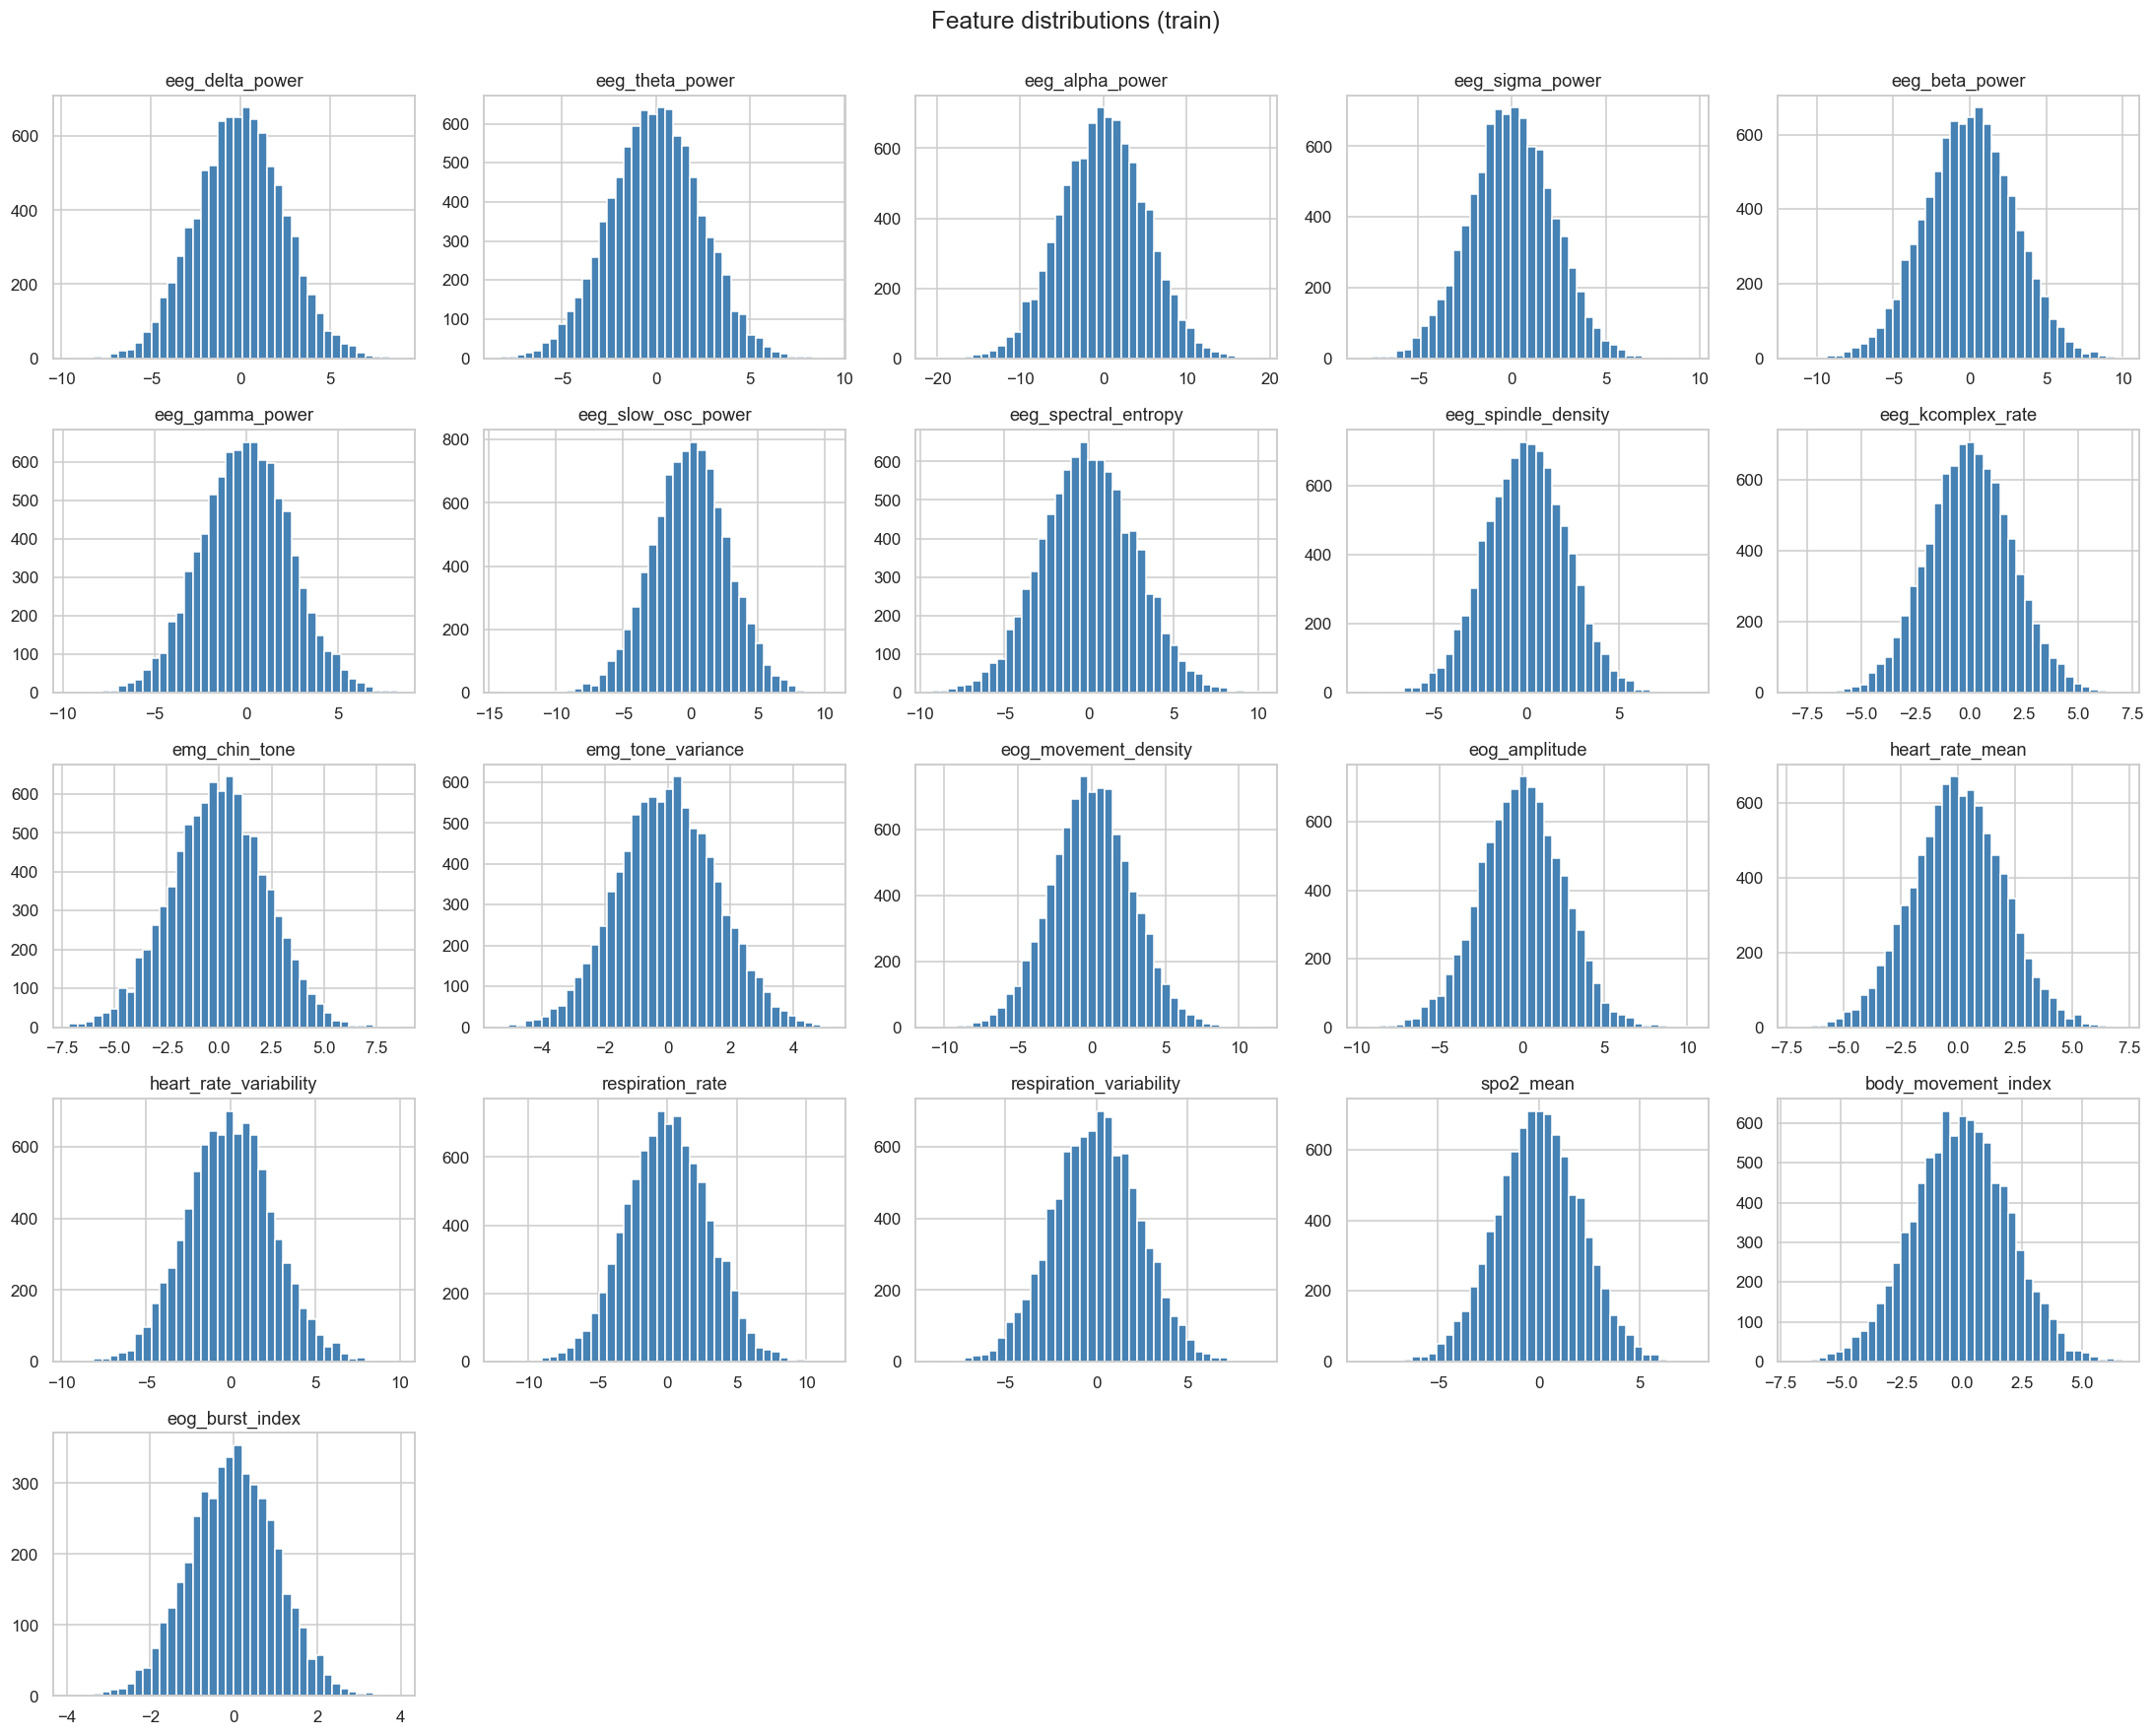

In [11]:
train[FEATURES].hist(bins=40, figsize=(20, 16), color="steelblue", edgecolor="white")
plt.suptitle("Feature distributions (train)", y=1.0, fontsize=16)
plt.tight_layout()
plt.show()

## 9. Correlation heatmap
Which features move together, and which line up with the target.

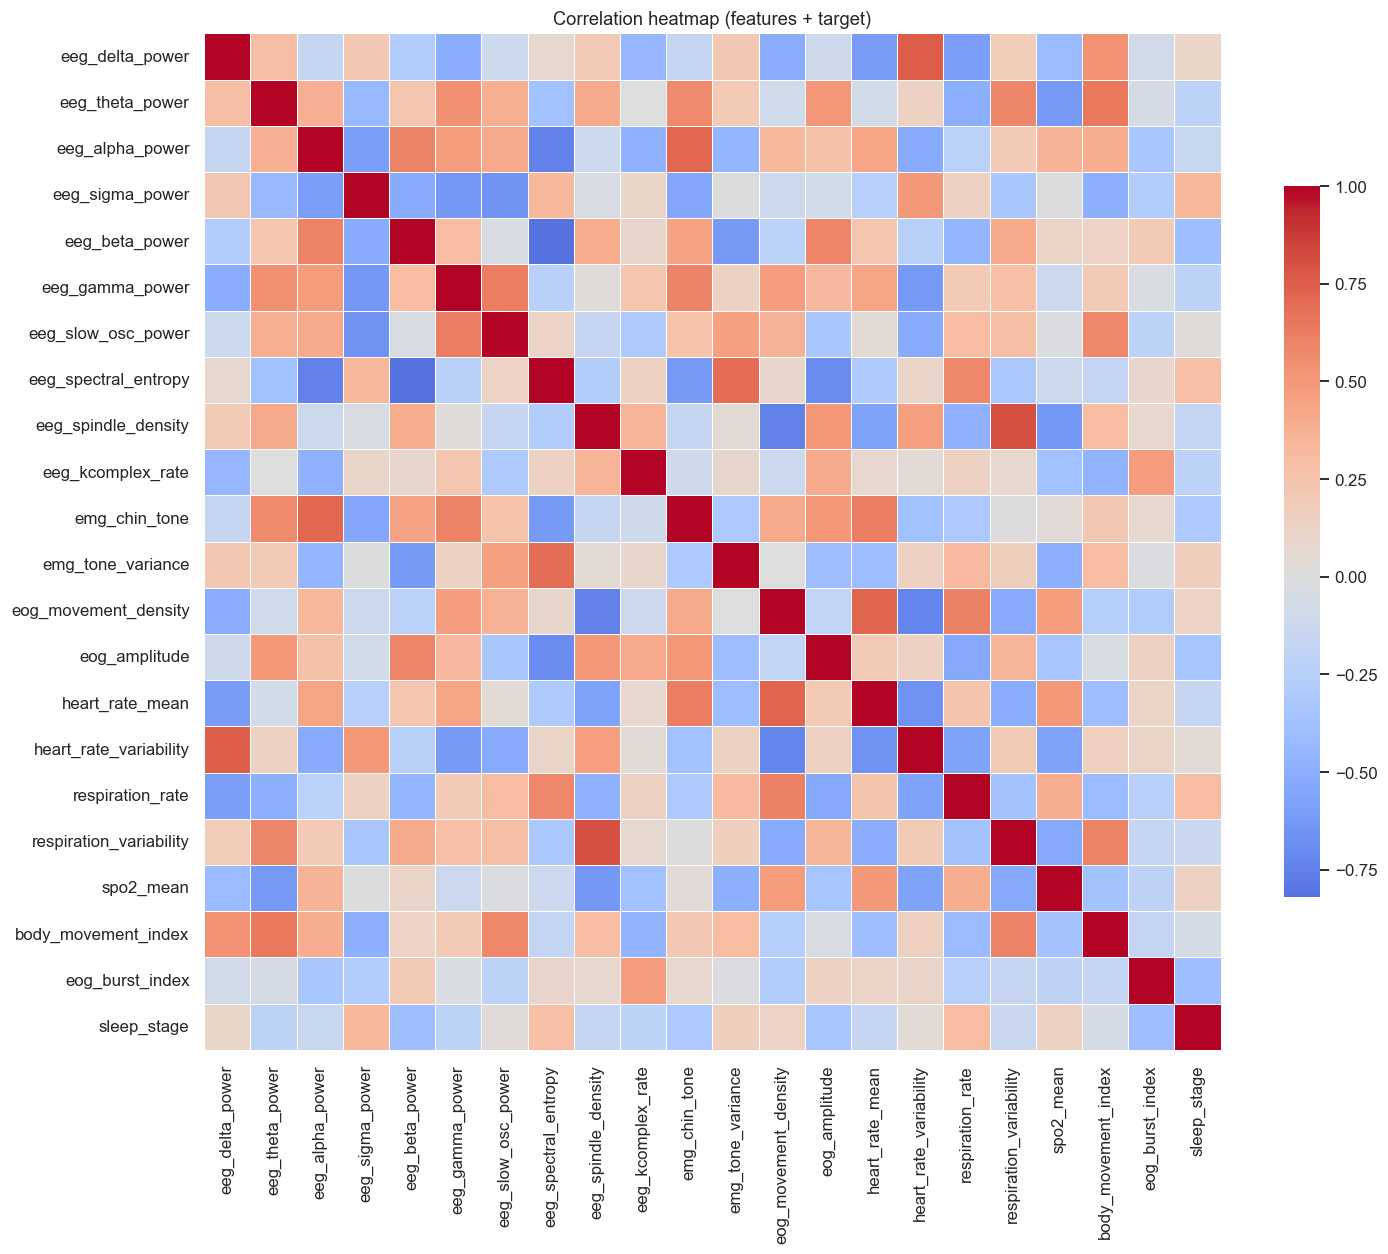

In [12]:
plt.figure(figsize=(15, 12))
corr = train[FEATURES + [TARGET]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.7})
plt.title("Correlation heatmap (features + target)")
plt.show()

In [13]:
# Linear correlation of each feature with the target (rough hint — target is categorical)
target_corr = train[FEATURES].corrwith(train[TARGET]).sort_values(key=abs, ascending=False)
print("Correlation of each feature with sleep_stage (sorted by |corr|):")
print(target_corr.round(3))

Correlation of each feature with sleep_stage (sorted by |corr|):
eog_burst_index           -0.400
eeg_beta_power            -0.398
eog_amplitude             -0.347
eeg_sigma_power            0.333
emg_chin_tone             -0.311
respiration_rate           0.297
eeg_spectral_entropy       0.287
eeg_theta_power           -0.223
eeg_kcomplex_rate         -0.220
eeg_gamma_power           -0.217
eeg_spindle_density       -0.179
emg_tone_variance          0.169
heart_rate_mean           -0.160
eeg_alpha_power           -0.147
spo2_mean                  0.143
respiration_variability   -0.135
eog_movement_density       0.128
eeg_delta_power            0.106
body_movement_index       -0.059
heart_rate_variability     0.040
eeg_slow_osc_power         0.027
dtype: float64


## 10. How each feature separates the stages (boxplots)
This is the most useful EDA view for classification — features whose boxes sit at
**different levels per stage** are the ones the model will lean on.

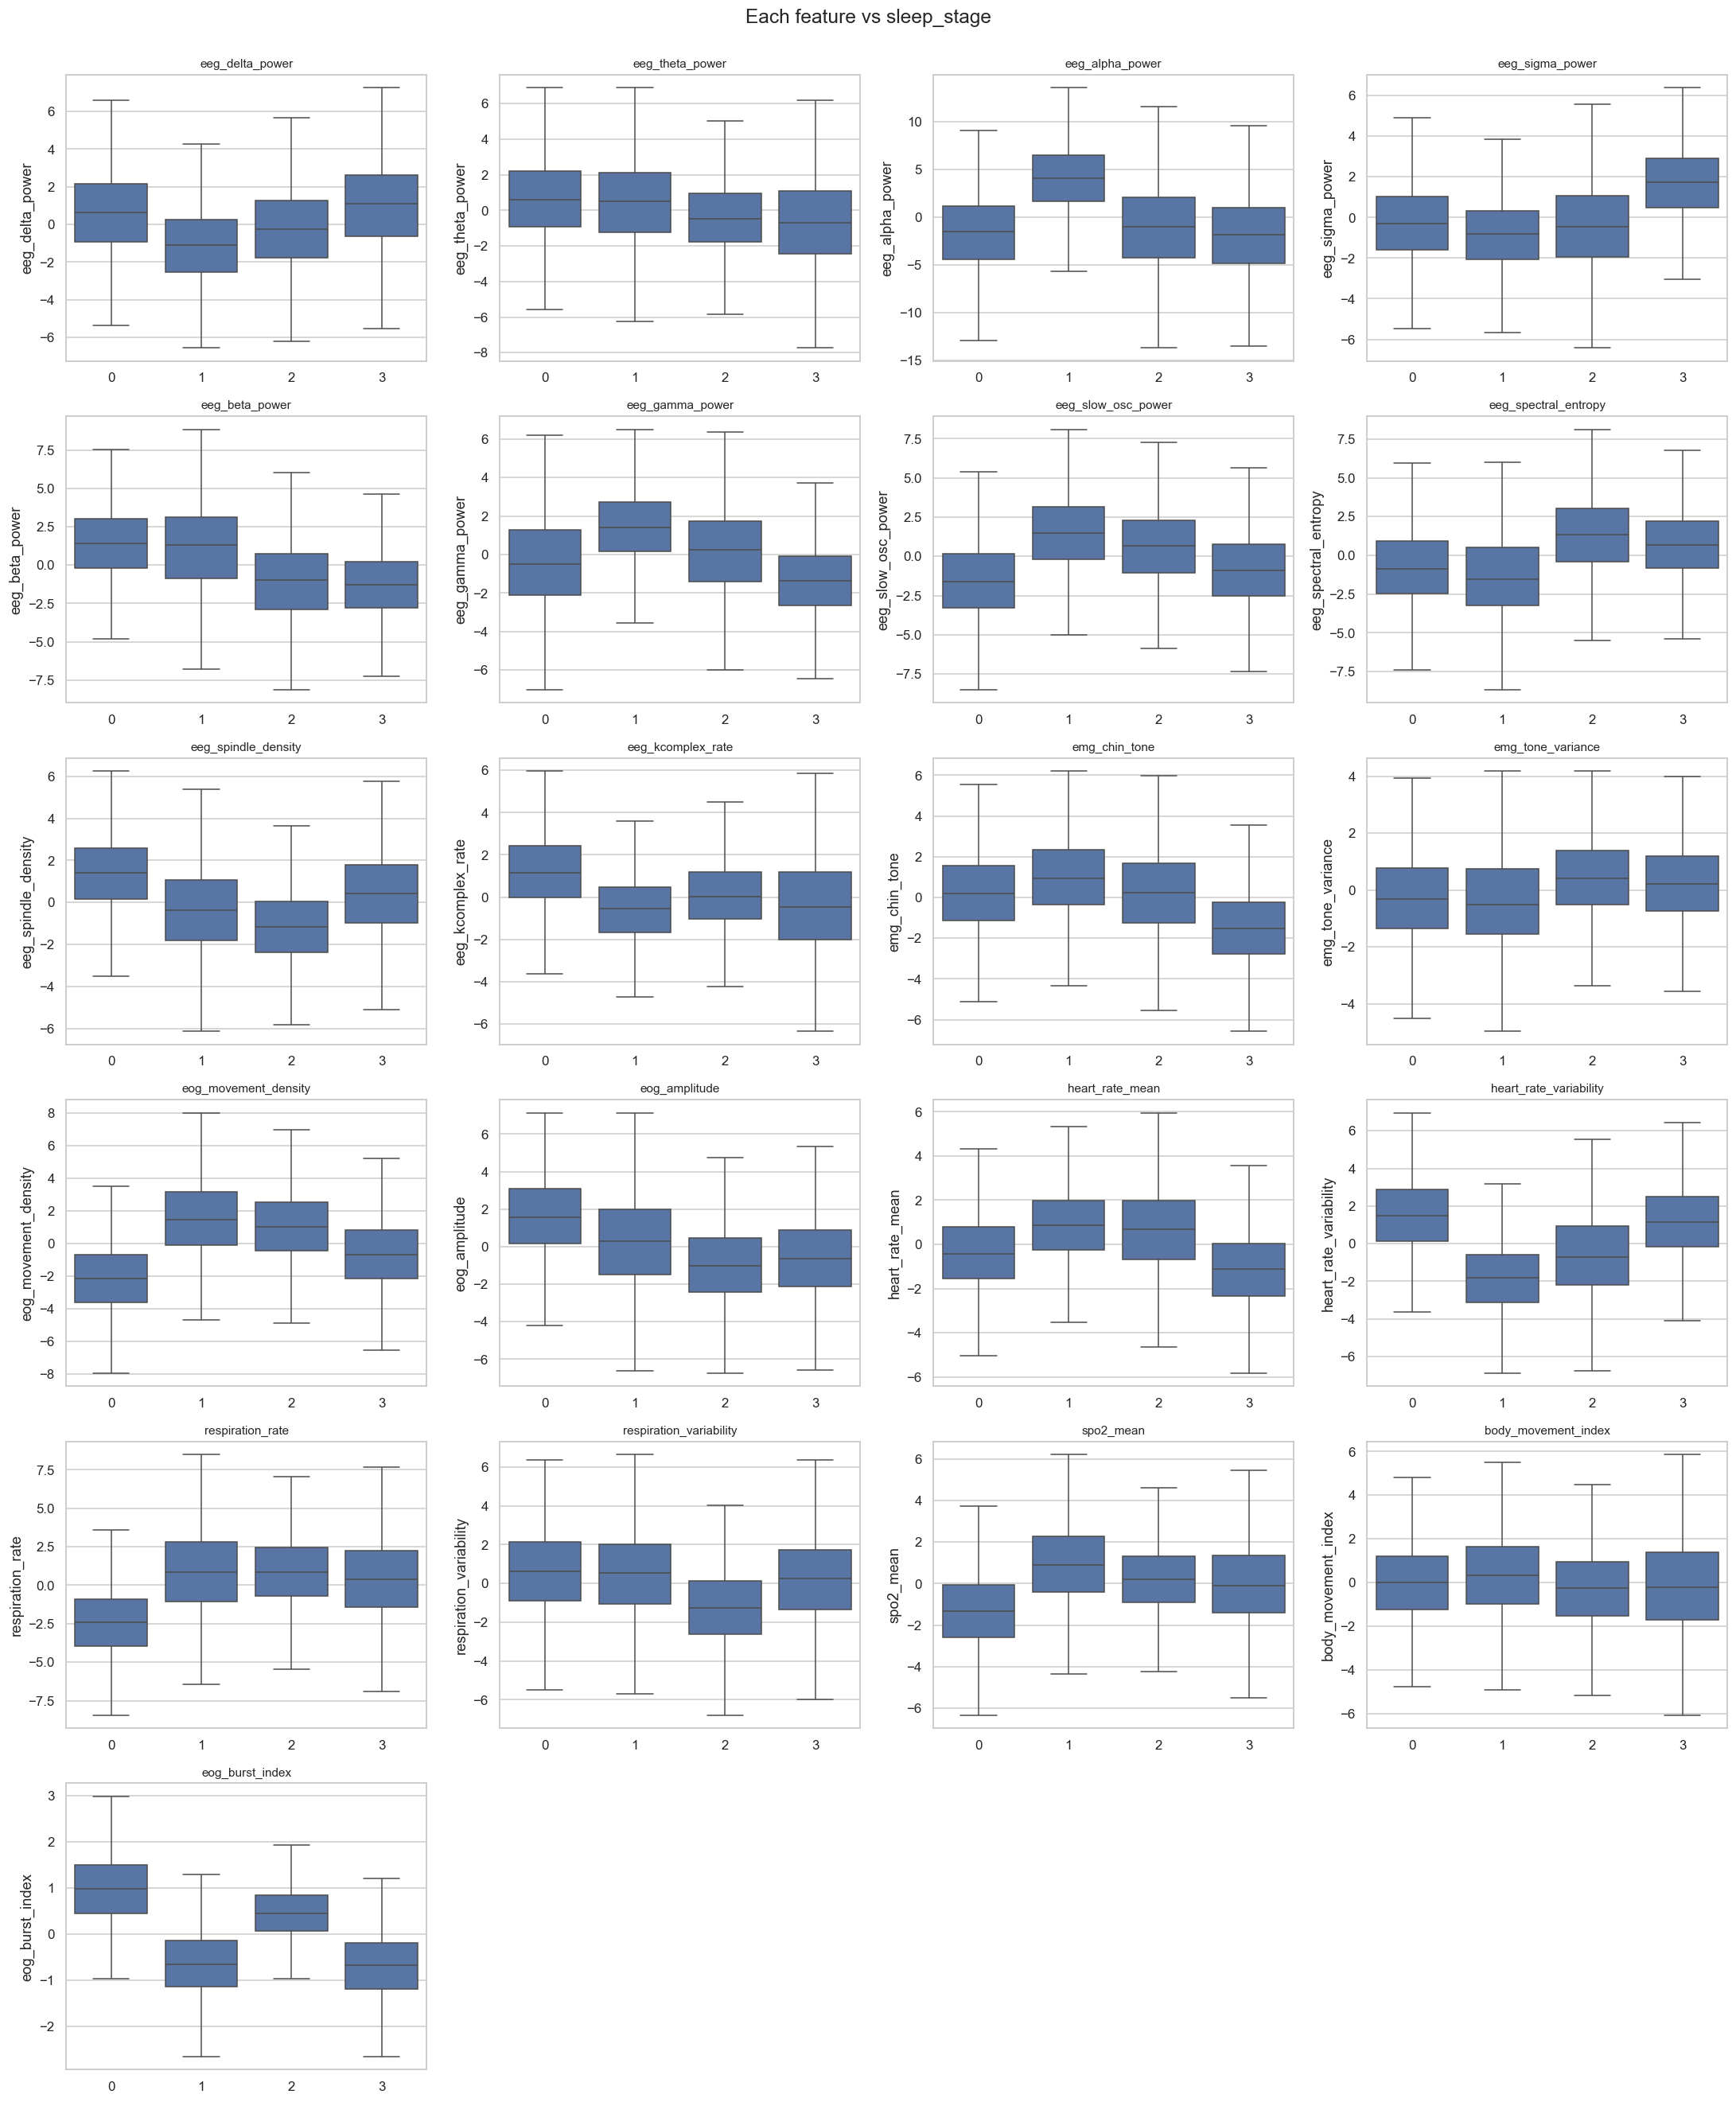

In [14]:
n = len(FEATURES)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
for ax, col in zip(axes.flat, FEATURES):
    sns.boxplot(data=train, x=TARGET, y=col, ax=ax, showfliers=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
for ax in axes.flat[n:]:
    ax.axis("off")
plt.suptitle("Each feature vs sleep_stage", y=1.0, fontsize=16)
plt.tight_layout()
plt.show()

## 11. Pairplot of the most stage-relevant features
A curated subset (a full 21×21 pairplot would be unreadable), coloured by stage,
to see how classes cluster in 2-D.

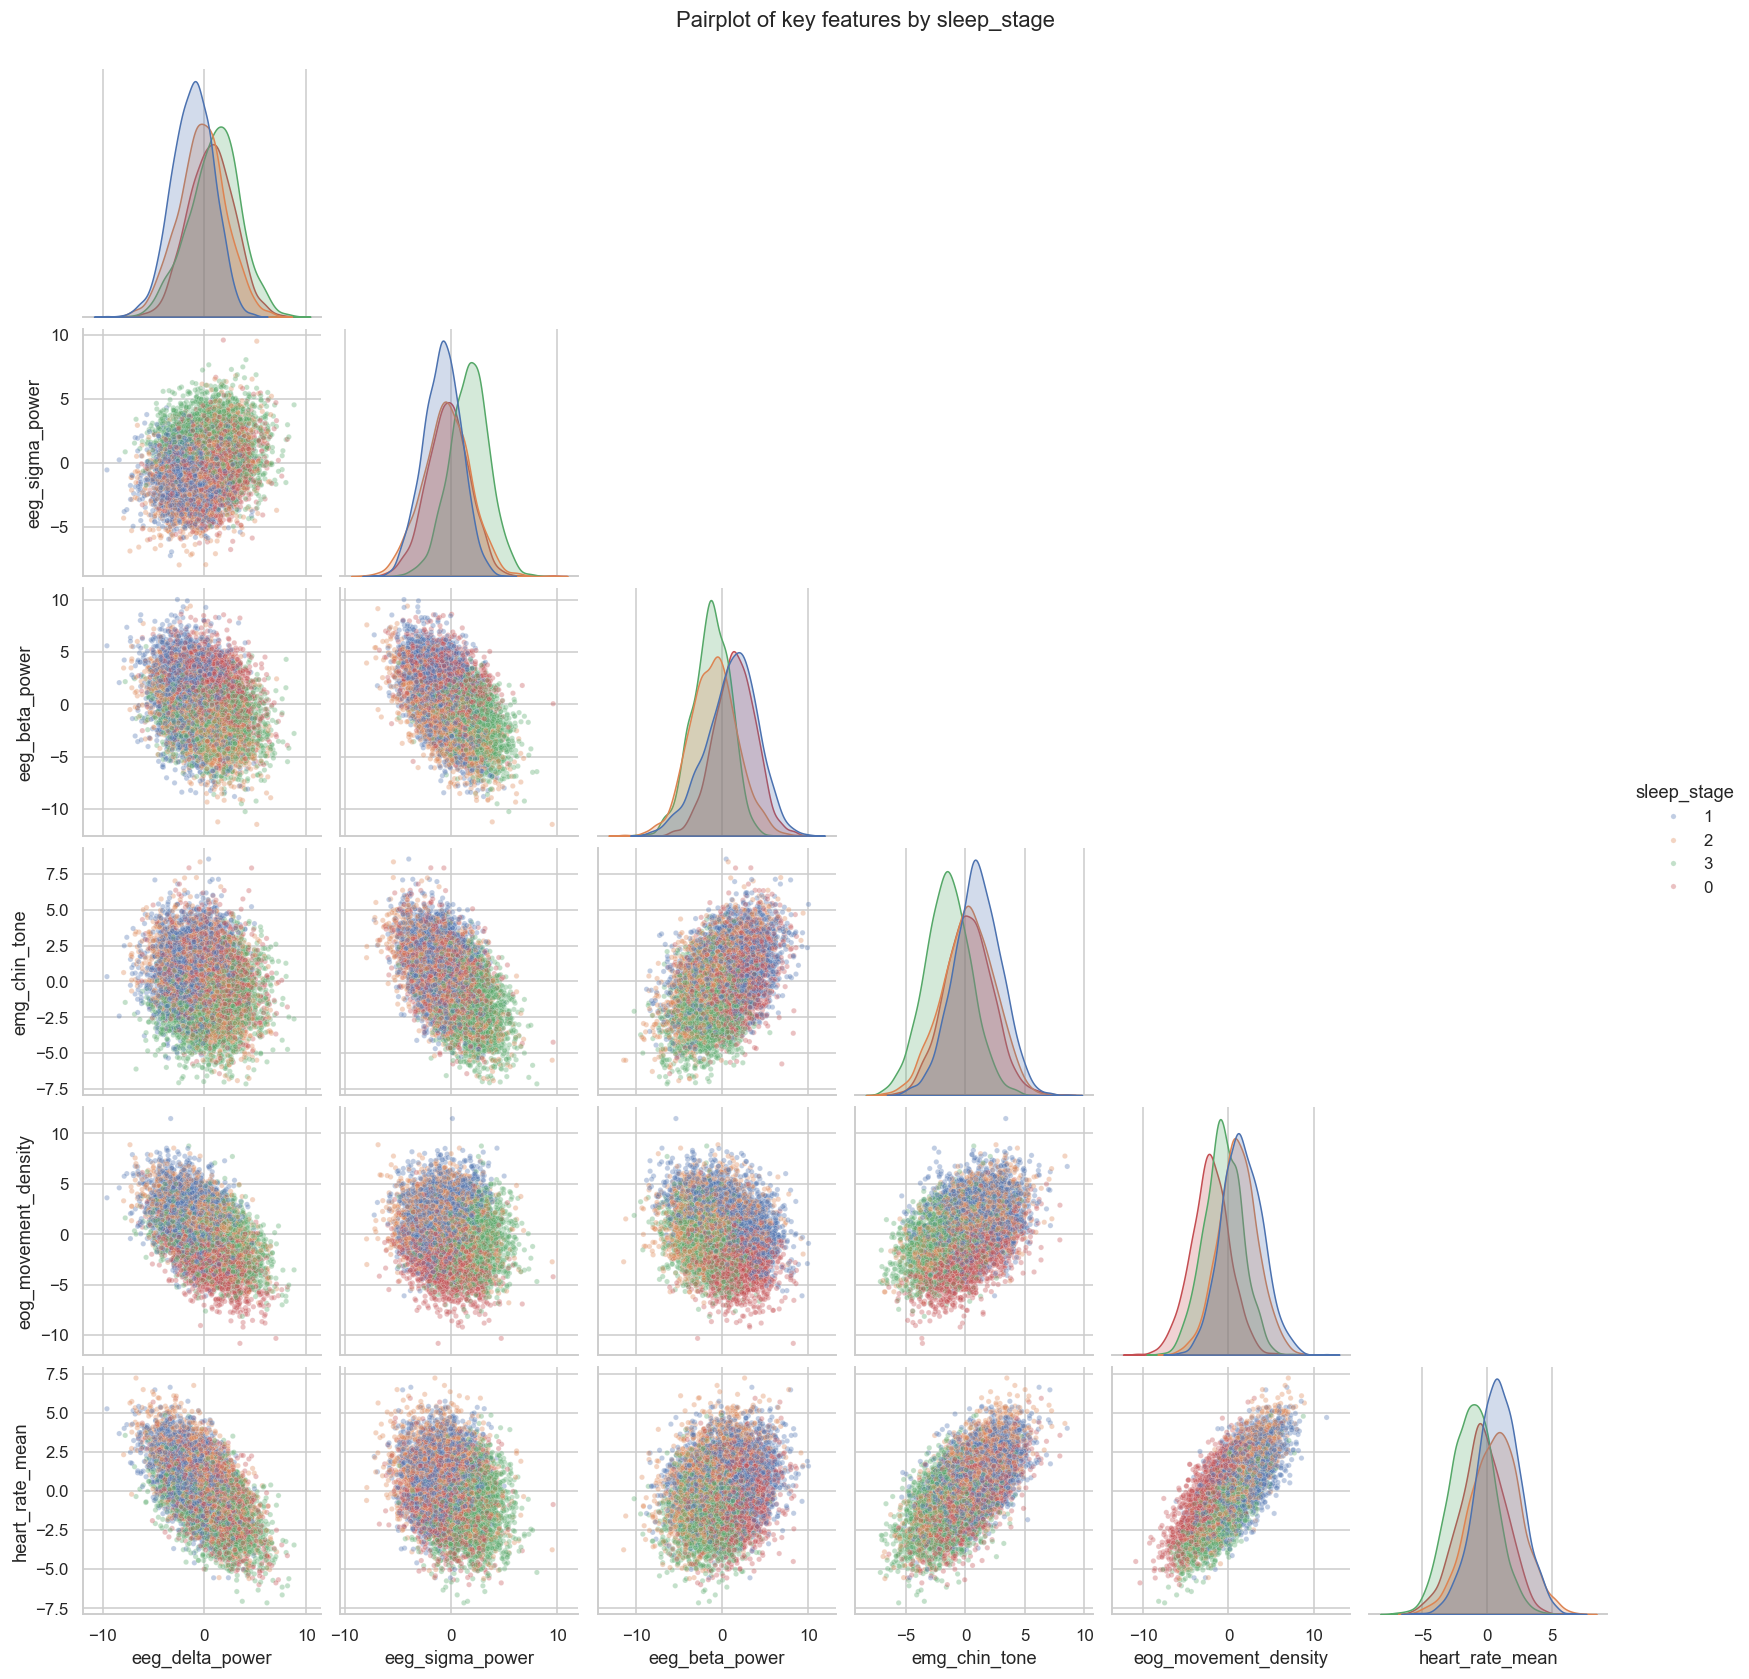

In [15]:
key_feats = [
    "eeg_delta_power",      # deep-sleep marker
    "eeg_sigma_power",      # stage-2 spindle band
    "eeg_beta_power",       # wakefulness
    "emg_chin_tone",        # muscle tone (low in REM)
    "eog_movement_density", # eye movement (high in REM)
    "heart_rate_mean",      # autonomic
]
pp = train[key_feats + [TARGET]].copy()
pp[TARGET] = pp[TARGET].astype(str)
sns.pairplot(pp, hue=TARGET, diag_kind="kde",
             plot_kws={"alpha": 0.35, "s": 12}, corner=True)
plt.suptitle("Pairplot of key features by sleep_stage", y=1.02)
plt.show()

## 12. Takeaways (fill in as you read the plots)

- **Shape:** 9,000 train rows, 5,000 test rows, 21 features, target `sleep_stage` (4 classes).
- **Balance:** classes are roughly even → majority-class baseline ≈ 27% accuracy.
- **Missing data:** only `eog_burst_index` (~50%). Decide: median-fill, add a missing-flag, or both.
- **Most discriminative features:** _(note the ones whose boxplots separate stages — e.g. delta, sigma, chin tone, eye movement)_
- **Correlations / redundancy:** _(note any strongly correlated feature pairs)_
- **Next step:** train/validation split + a multi-class classifier (your own code).

## 13. Per-stage statistics — mean / min / max of every feature

Here we line up each feature's **mean, min and max within each of the 4 sleep stages**,
so we can read across a row and see how the values shift from stage to stage.

### 13a. Means table (sorted by how much the mean moves across stages)
`mean_spread` = (largest stage-mean − smallest stage-mean). Features at the **top**
are the ones whose average level changes most between stages — the strongest separators.

In [16]:
# Mean of every feature, per sleep stage (features = rows, stages = columns)
stage_cols = [f"stage_{c}" for c in sorted(train[TARGET].unique())]

stage_means = train.groupby(TARGET)[FEATURES].mean().T
stage_means.columns = stage_cols

# how far the mean travels across the 4 stages (bigger = better separator)
stage_means["mean_spread"] = stage_means[stage_cols].max(axis=1) - stage_means[stage_cols].min(axis=1)
stage_means = stage_means.sort_values("mean_spread", ascending=False)

stage_means.round(3)

,stage_0,stage_1,stage_2,stage_3,mean_spread
eeg_alpha_power,-1.744,4.053,-0.979,-1.882,5.935
eog_movement_density,-2.172,1.547,1.045,-0.679,3.719
heart_rate_variability,1.569,-1.899,-0.639,1.179,3.468
respiration_rate,-2.425,0.920,0.844,0.441,3.346
eeg_slow_osc_power,-1.611,1.495,0.641,-0.858,3.107
eeg_gamma_power,-0.422,1.475,0.180,-1.404,2.879
eeg_beta_power,1.405,1.045,-1.036,-1.351,2.755
eog_amplitude,1.617,0.213,-1.025,-0.658,2.642
eeg_spindle_density,1.417,-0.375,-1.222,0.376,2.639
eeg_sigma_power,-0.302,-0.871,-0.465,1.673,2.544


### 13b. Full mean / min / max table
Each feature shows three rows — **mean, min, max** — side by side across the 4 stages
(ordered with the strongest separators first).

In [17]:
full = train.groupby(TARGET)[FEATURES].agg(["mean", "min", "max"]).T
full.columns = stage_cols
full.index.names = ["feature", "stat"]
full = full.reindex(stage_means.index, level="feature")   # order by separating power

with pd.option_context("display.max_rows", None):
    display(full.round(3))

stage_0  stage_1  stage_2  stage_3
feature                 stat                                    
eeg_alpha_power         mean   -1.744    4.053   -0.979   -1.882
                        min   -18.789  -12.583  -20.632  -20.088
                        max    11.405   18.870   14.965   14.420
eog_movement_density    mean   -2.172    1.547    1.045   -0.679
                        min   -10.835   -6.115   -6.811   -8.157
                        max     6.120   11.472    8.873    8.746
heart_rate_variability  mean    1.569   -1.899   -0.639    1.179
                        min    -4.853   -9.023   -9.544   -4.814
                        max     9.895    4.040    8.680    9.281
respiration_rate        mean   -2.425    0.920    0.844    0.441
                        min   -11.997  -10.229   -8.311  -11.301
                        max     7.032   11.664    8.316   10.456
eeg_slow_osc_power      mean   -1.611    1.495    0.641   -0.858
                        min   -14.123   -6.877   -8.648   -9.868
                        max     6.503   10.362    8.999    7.014
eeg_gamma_power         mean   -0.422    1.475    0.180   -1.404
                        min    -9.638   -5.941   -8.544   -8.839
                        max     8.281    8.296    8.113    5.129
eeg_beta_power          mean    1.405    1.045   -1.036   -1.351
                        min    -6.267   -8.796  -11.460  -10.237
                        max     8.626   10.027    9.403    5.537
eog_amplitude           mean    1.617    0.213   -1.025   -0.658
                        min    -5.827   -8.392   -9.615   -8.845
                        max    10.286    8.476    5.376    6.383
eeg_spindle_density     mean    1.417   -0.375   -1.222    0.376
                        min    -4.441   -7.698   -8.828   -7.319
                        max     8.937    7.027    4.290    6.273
eeg_sigma_power         mean   -0.302   -0.871   -0.465    1.673
                        min    -6.748   -7.227   -7.948   -4.945
                        max     9.603    4.995    9.514    8.072
eeg_spectral_entropy    mean   -0.737   -1.253    1.280    0.759
                        min    -9.019   -9.301   -8.095   -7.370
                        max     8.195    8.418   10.160    9.161
emg_chin_tone           mean    0.226    0.971    0.206   -1.503
                        min    -6.439   -5.356   -6.927   -7.153
                        max     7.940    8.553    8.356    4.720
spo2_mean               mean   -1.309    0.938    0.225   -0.034
                        min    -8.704   -5.158   -4.958   -5.926
                        max     5.762    7.018    5.411    7.565
eeg_delta_power         mean    0.604   -1.172   -0.287    0.930
                        min    -6.465   -9.567   -7.930   -7.773
                        max     8.141    4.910    7.082    8.798
heart_rate_mean         mean   -0.394    0.846    0.637   -1.147
                        min    -5.997   -5.558   -5.609   -7.160
                        max     5.919    6.623    7.215    4.837
respiration_variability mean    0.616    0.467   -1.279    0.204
                        min    -6.685   -7.470   -9.021   -7.226
                        max     7.482    9.011    5.045    7.398
eeg_kcomplex_rate       mean    1.191   -0.602    0.056   -0.421
                        min    -5.368   -6.366   -5.941   -8.090
                        max     6.808    4.164    4.760    7.064
eog_burst_index         mean    0.987   -0.647    0.480   -0.706
                        min    -3.513   -3.184   -1.229   -3.936
                        max     3.936    2.247    2.380    2.012
eeg_theta_power         mean    0.660    0.383   -0.432   -0.688
                        min    -8.135   -8.277   -7.011   -7.780
                        max     9.222    8.043    6.674    7.058
emg_tone_variance       mean   -0.282   -0.391    0.445    0.230
                        min    -5.025   -5.317   -4.812   -4.438
                        max     5.143    4.860    4.846    4.691


### 13c. Heatmap of the means
The same means as a colour grid — easy to spot at a glance *where* each feature sits
per stage (red = high, blue = low). Rows ordered by separating power.

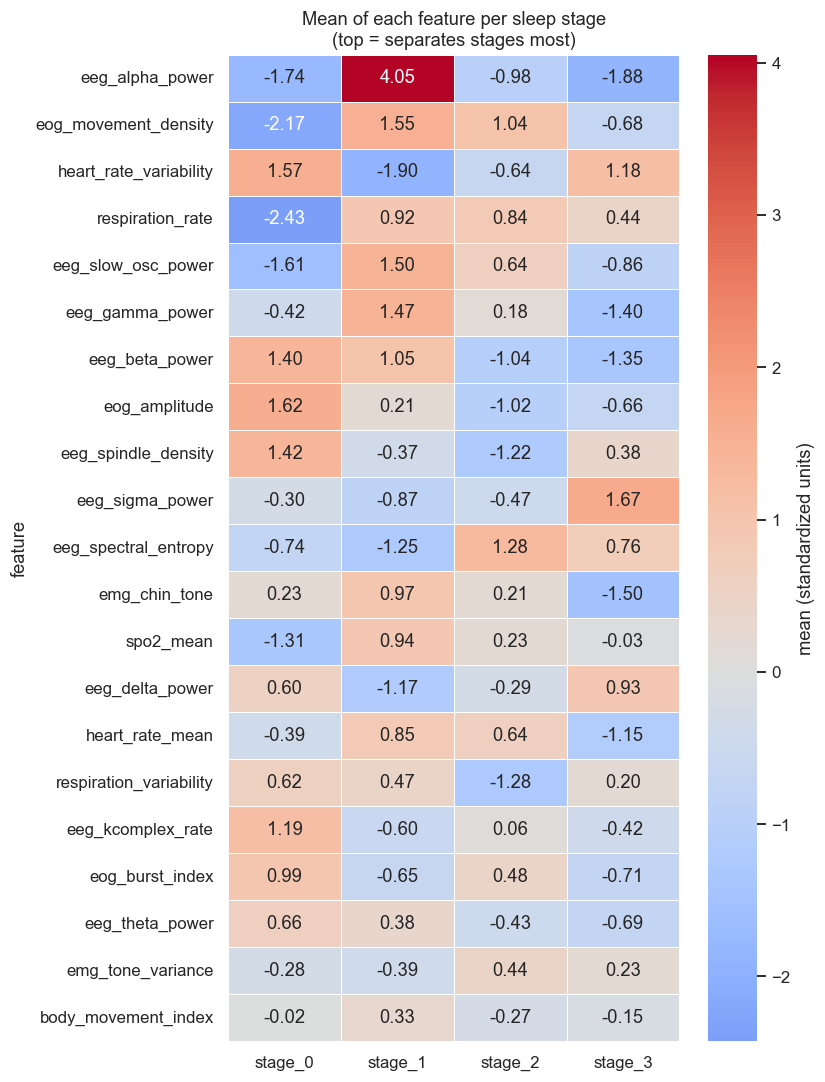

In [18]:
plt.figure(figsize=(7.5, 10))
sns.heatmap(stage_means[stage_cols], annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"label": "mean (standardized units)"})
plt.title("Mean of each feature per sleep stage\n(top = separates stages most)")
plt.xlabel(""); plt.ylabel("feature")
plt.tight_layout()
plt.show()

### 13d. `eog_burst_index` — means per stage (plot)
Our strongest single feature. Bars = mean per stage, error bars = std.

             count   mean    std    min    max
sleep_stage                                   
0             1029  0.987  0.823 -3.513  3.936
1             1230 -0.647  0.789 -3.184  2.247
2             1109  0.480  0.560 -1.229  2.380
3             1131 -0.706  0.789 -3.936  2.012


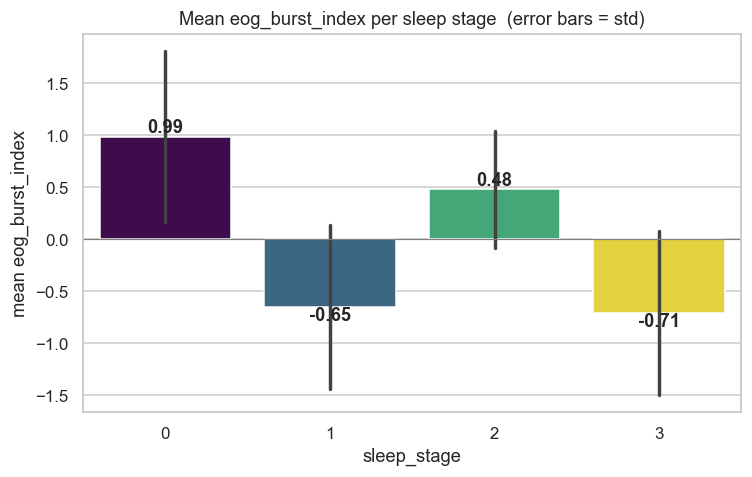

In [19]:
eb = train.groupby(TARGET)["eog_burst_index"].agg(["count", "mean", "std", "min", "max"]).round(3)
print(eb)

plt.figure(figsize=(7, 4.5))
ax = sns.barplot(data=train, x=TARGET, y="eog_burst_index", hue=TARGET,
                 estimator="mean", errorbar="sd", palette="viridis", legend=False)
ax.set_title("Mean eog_burst_index per sleep stage  (error bars = std)")
ax.set_xlabel("sleep_stage"); ax.set_ylabel("mean eog_burst_index")
ax.axhline(0, color="grey", lw=0.8)
for i, m in enumerate(eb["mean"]):
    ax.text(i, m, f"{m:.2f}", ha="center",
            va="bottom" if m >= 0 else "top", fontweight="bold")
plt.tight_layout()
plt.show()

## 14. Multicollinearity — feature ↔ feature correlation & VIF

**Important distinction:** earlier (§9) the ~0.40 numbers were each feature's correlation
with the **target**. Multicollinearity is different — it's how much features correlate with
**each other**. Redundant features make linear-model coefficients unstable and *split*
feature-importance in trees (though they don't hurt a tree's accuracy).

We use a train-median fill for `eog_burst_index` here just so the diagnostic has no gaps.

### 14a. Strongest feature ↔ feature correlations

In [20]:
# Feature matrix with eog_burst_index median-filled (for this diagnostic only)
X = train[FEATURES].copy()
X["eog_burst_index"] = X["eog_burst_index"].fillna(X["eog_burst_index"].median())

corr = X.corr()
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)        # upper triangle only
pairs = corr.where(mask).stack().sort_values(key=abs, ascending=False)

top_pairs = pairs.head(12).rename("corr").reset_index()
top_pairs.columns = ["feature_A", "feature_B", "corr"]
top_pairs.round(3)

,feature_A,feature_B,corr
0,eeg_beta_power,eeg_spectral_entropy,-0.821
1,eeg_spindle_density,respiration_variability,0.802
2,eeg_delta_power,heart_rate_variability,0.760
3,eeg_alpha_power,eeg_spectral_entropy,-0.750
4,eeg_spindle_density,eog_movement_density,-0.743
5,eog_movement_density,heart_rate_mean,0.729
6,eog_movement_density,heart_rate_variability,-0.726
7,eeg_alpha_power,emg_chin_tone,0.722
8,eeg_spectral_entropy,emg_tone_variance,0.696
9,eeg_spectral_entropy,eog_amplitude,-0.694


### 14b. Variance Inflation Factor (VIF)
`VIF` = 1 / (1 − R²) when a feature is regressed on all the others — equivalently the
diagonal of the inverse correlation matrix. **Rule of thumb: >5 moderate, >10 high.**

In [21]:
vif = pd.Series(np.diag(np.linalg.inv(corr.values)), index=FEATURES).sort_values(ascending=False)
vif_df = vif.rename("VIF").to_frame()
vif_df["flag"] = pd.cut(vif_df["VIF"], [0, 5, 10, np.inf],
                        labels=["ok", "moderate (>5)", "high (>10)"])
print("mean VIF:", round(vif.mean(), 2), "| max VIF:", round(vif.max(), 2))
vif_df.round(2)

mean VIF: 10.98 | max VIF: 25.44


,VIF,flag
eeg_alpha_power,25.44,high (>10)
eeg_spectral_entropy,15.92,high (>10)
heart_rate_variability,13.69,high (>10)
respiration_rate,13.64,high (>10)
eeg_slow_osc_power,13.53,high (>10)
eeg_beta_power,13.32,high (>10)
eog_movement_density,13.25,high (>10)
eeg_gamma_power,11.50,high (>10)
eog_amplitude,11.01,high (>10)
eeg_delta_power,10.77,high (>10)


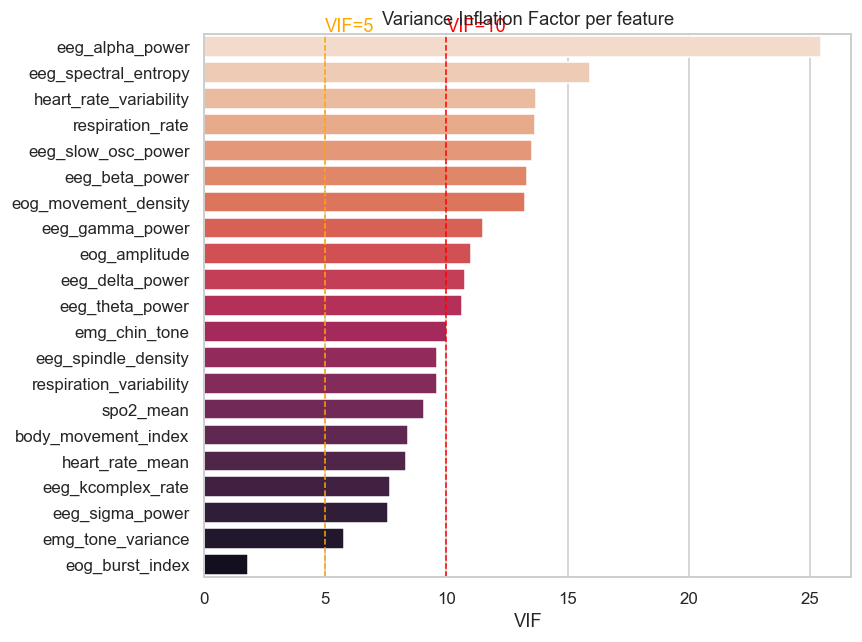

In [22]:
plt.figure(figsize=(8, 6))
sns.barplot(x=vif.values, y=vif.index, hue=vif.index, palette="rocket_r", legend=False)
plt.axvline(5, color="orange", ls="--", lw=1)
plt.axvline(10, color="red", ls="--", lw=1)
plt.text(5, -0.6, "VIF=5", color="orange"); plt.text(10, -0.6, "VIF=10", color="red")
plt.title("Variance Inflation Factor per feature")
plt.xlabel("VIF"); plt.ylabel("")
plt.tight_layout()
plt.show()

**Reading it:** mean VIF ~11, several features >10 → real multicollinearity (physiologically
sensible: e.g. beta power ↔ spectral entropy both track "busy/awake" brain). `eog_burst_index`
stands out with VIF ~1.8 — nearly independent, hence non-redundant and valuable.

**What to do:** for a **tree model**, don't drop anything — accuracy is unaffected (just don't
over-trust importance). For a **linear model**, use L2/ridge regularisation rather than deleting
columns. With 21 features and 9,000 rows, dropping features mostly throws away signal.

## 15. PCA — visualising the redundancy

Principal Component Analysis re-expresses the 21 correlated features as **orthogonal
(uncorrelated) components**. If there's heavy redundancy, a handful of components will
capture most of the variance.

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Xs = StandardScaler().fit_transform(X)        # X = median-filled features from section 14
pca = PCA().fit(Xs)

evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)
n80 = int(np.argmax(cum >= 0.80) + 1)
n90 = int(np.argmax(cum >= 0.90) + 1)
print(f"{len(evr)} features -> {n80} components reach 80% variance, {n90} reach 90%")

comp_df = pd.DataFrame({
    "component": np.arange(1, len(evr) + 1),
    "explained_var": evr.round(3),
    "cumulative": cum.round(3),
})
comp_df.head(21)

21 features -> 4 components reach 80% variance, 6 reach 90%


,component,explained_var,cumulative
0,1,0.271,0.271
1,2,0.263,0.535
2,3,0.162,0.696
3,4,0.119,0.815
4,5,0.069,0.884
5,6,0.056,0.941
6,7,0.012,0.953
7,8,0.006,0.959
8,9,0.005,0.964
9,10,0.004,0.968


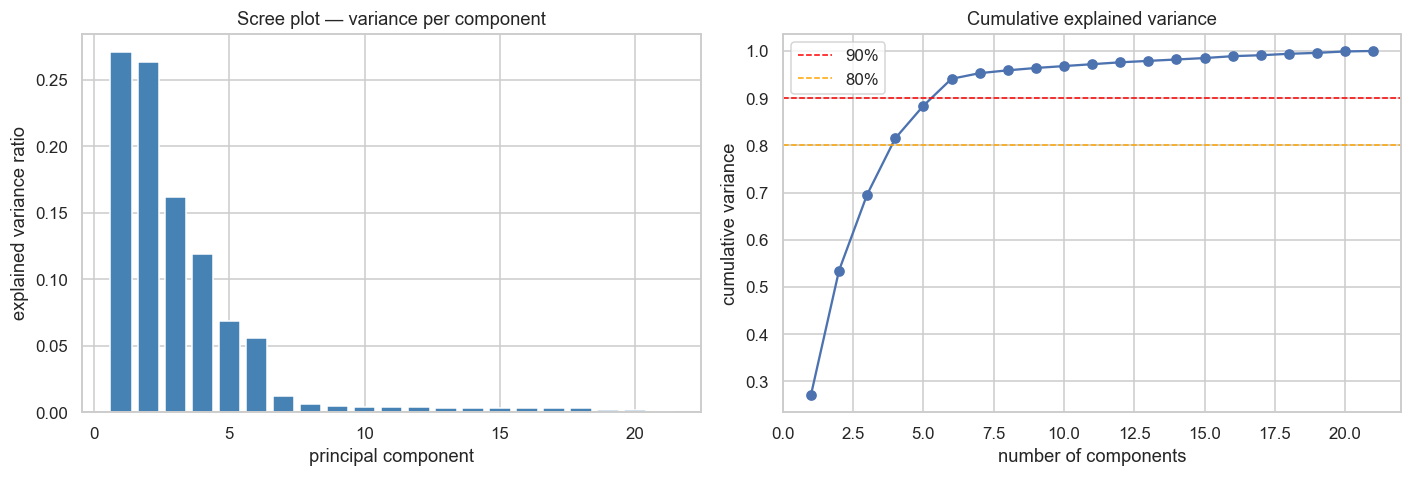

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(comp_df["component"], comp_df["explained_var"], color="steelblue")
axes[0].set_title("Scree plot — variance per component")
axes[0].set_xlabel("principal component"); axes[0].set_ylabel("explained variance ratio")

axes[1].plot(comp_df["component"], comp_df["cumulative"], marker="o")
axes[1].axhline(0.90, color="red", ls="--", lw=1, label="90%")
axes[1].axhline(0.80, color="orange", ls="--", lw=1, label="80%")
axes[1].set_title("Cumulative explained variance")
axes[1].set_xlabel("number of components"); axes[1].set_ylabel("cumulative variance")
axes[1].legend()
plt.tight_layout()
plt.show()

### 15a. First two components, coloured by sleep stage
A quick look at how separable the four stages are in 2-D (PC1 vs PC2).

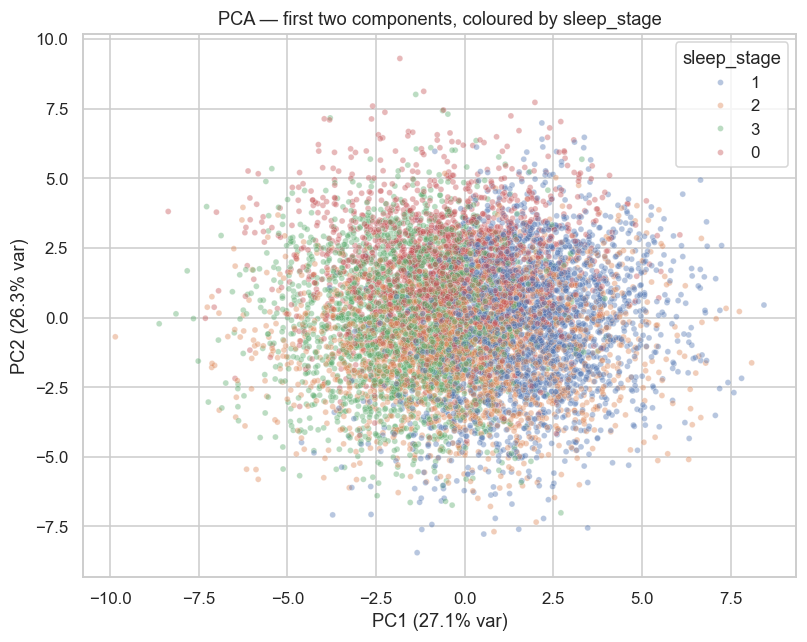

In [25]:
coords = pca.transform(Xs)[:, :2]
plt.figure(figsize=(7.5, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=train[TARGET].astype(str),
                palette="deep", alpha=0.4, s=15)
plt.title("PCA — first two components, coloured by sleep_stage")
plt.xlabel(f"PC1 ({evr[0]*100:.1f}% var)"); plt.ylabel(f"PC2 ({evr[1]*100:.1f}% var)")
plt.legend(title="sleep_stage")
plt.tight_layout()
plt.show()

**Note:** PCA is a *visualisation / linear-model* aid here, not something you must feed the
model. Tree ensembles handle the raw correlated features fine. Use PCA if you go linear, or
just to *see* how much overlap there is between stages.

## 16. Can we name the stages? Verifying textbook signatures

We test whether the classic polysomnography signatures hold:
- **Wake** — high muscle tone, movement, alpha/beta, heart rate
- **Light (N2)** — sleep spindles + K-complexes
- **Deep (N3)** — high delta / slow oscillations, low arousal
- **REM** — high eye movement **with** muscle atonia (low chin EMG)

For each marker we find which stage is the extreme, then check whether a consistent
one-to-one mapping emerges — or whether the signatures contradict each other.

### 16a. Signature scorecard
For each canonical marker: which stage is the extreme, and the 4 stage-means.

In [26]:
m = train.groupby(TARGET)[FEATURES].mean()           # rows = stage
stages = sorted(train[TARGET].unique())

signatures = [
    ("Wake",  "eeg_alpha_power",         "high"),
    ("Wake",  "eeg_beta_power",          "high"),
    ("Wake",  "emg_chin_tone",           "high"),
    ("Wake",  "body_movement_index",     "high"),
    ("Wake",  "heart_rate_mean",         "high"),
    ("Light", "eeg_spindle_density",     "high"),
    ("Light", "eeg_kcomplex_rate",       "high"),
    ("Light", "eeg_sigma_power",         "high"),
    ("Deep",  "eeg_delta_power",         "high"),
    ("Deep",  "eeg_slow_osc_power",      "high"),
    ("Deep",  "heart_rate_variability",  "high"),
    ("Deep",  "eeg_spectral_entropy",    "low"),
    ("REM",   "eog_movement_density",    "high"),
    ("REM",   "eog_amplitude",           "high"),
    ("REM",   "eog_burst_index",         "high"),
    ("REM",   "respiration_variability", "high"),
    ("REM",   "emg_chin_tone",           "low"),
]
rows = []
for role, feat, direction in signatures:
    extreme = int(m[feat].idxmax() if direction == "high" else m[feat].idxmin())
    rows.append({"textbook_role": role, "marker": feat, "expect": direction,
                 "extreme_stage": extreme,
                 **{f"stage_{s}": round(m.loc[s, feat], 2) for s in stages}})
scorecard = pd.DataFrame(rows)
scorecard

,textbook_role,marker,expect,extreme_stage,stage_0,stage_1,stage_2,stage_3
0,Wake,eeg_alpha_power,high,1,-1.74,4.05,-0.98,-1.88
1,Wake,eeg_beta_power,high,0,1.40,1.05,-1.04,-1.35
2,Wake,emg_chin_tone,high,1,0.23,0.97,0.21,-1.50
3,Wake,body_movement_index,high,1,-0.02,0.33,-0.27,-0.15
4,Wake,heart_rate_mean,high,1,-0.39,0.85,0.64,-1.15
5,Light,eeg_spindle_density,high,0,1.42,-0.37,-1.22,0.38
6,Light,eeg_kcomplex_rate,high,0,1.19,-0.60,0.06,-0.42
7,Light,eeg_sigma_power,high,3,-0.30,-0.87,-0.47,1.67
8,Deep,eeg_delta_power,high,3,0.60,-1.17,-0.29,0.93
9,Deep,eeg_slow_osc_power,high,1,-1.61,1.50,0.64,-0.86


### 16b. Vote tally — how many markers of each role point to each stage

In [27]:
votes = (scorecard.groupby("textbook_role")["extreme_stage"]
                  .value_counts().unstack(fill_value=0))
votes.columns = [f"stage_{c}" for c in votes.columns]
votes

,stage_0,stage_1,stage_3
textbook_role,,,
Deep,1,2,1
Light,2,0,1
REM,3,1,1
Wake,1,4,0


### 16c. The decisive REM test
REM is defined by **eye movement AND muscle atonia in the *same* stage**.

In [28]:
eog_stage    = int(m["eog_movement_density"].idxmax())
atonia_stage = int(m["emg_chin_tone"].idxmin())
print(f"Stage with MOST eye movement : {eog_stage}")
print(f"Stage with LOWEST chin tone  : {atonia_stage}   (muscle atonia)")
print("Same stage?  ->", eog_stage == atonia_stage)
print("\nREM needs BOTH together. If these differ, the REM signature has no home.")

Stage with MOST eye movement : 1
Stage with LOWEST chin tone  : 3   (muscle atonia)
Same stage?  -> False

REM needs BOTH together. If these differ, the REM signature has no home.


### 16d. Each stage's fingerprint (most distinctive features)

In [29]:
for s in stages:
    top = m.loc[s].sort_values(ascending=False)
    highs = ", ".join(f"{f} ({v:+.2f})" for f, v in top.head(3).items())
    lows  = ", ".join(f"{f} ({v:+.2f})" for f, v in top.tail(3).items())
    print(f"stage {s}:")
    print(f"   HIGH: {highs}")
    print(f"   LOW : {lows}")

stage 0:
   HIGH: eog_amplitude (+1.62), heart_rate_variability (+1.57), eeg_spindle_density (+1.42)
   LOW : eeg_alpha_power (-1.74), eog_movement_density (-2.17), respiration_rate (-2.43)
stage 1:
   HIGH: eeg_alpha_power (+4.05), eog_movement_density (+1.55), eeg_slow_osc_power (+1.50)
   LOW : eeg_delta_power (-1.17), eeg_spectral_entropy (-1.25), heart_rate_variability (-1.90)
stage 2:
   HIGH: eeg_spectral_entropy (+1.28), eog_movement_density (+1.04), respiration_rate (+0.84)
   LOW : eeg_beta_power (-1.04), eeg_spindle_density (-1.22), respiration_variability (-1.28)
stage 3:
   HIGH: eeg_sigma_power (+1.67), heart_rate_variability (+1.18), eeg_delta_power (+0.93)
   LOW : eeg_gamma_power (-1.40), emg_chin_tone (-1.50), eeg_alpha_power (-1.88)


### 16e. Verdict (first pass — extremes only)

`stage 1 = Wake` is clear. The other three contradict each other (REM test fails; within-family
markers like `delta`/`slow_osc` and `spindle_density`/`sigma_power` disagree) → strong sign the
data is **synthetic**. Section 17 refines this with the full cheat-sheet and an optimal assignment.

## 17. Best-fit stage mapping (cheat-sheet signatures + optimal assignment)

The numeric label (0–3) is **not** assumed to equal the stage number. We score every label
against each stage's cheat-sheet signature, then use the **Hungarian algorithm** to find the
best **one-to-one** assignment (so two stages can't grab the same label). Markers the cheat-sheet
bolds are weighted ×3 (delta for Deep, muscle atonia for REM).

### 17a. Signatures, score matrix & assignment

OPTIMAL assignment: {'Wake': 1, 'Deep': 2, 'REM': 3, 'Light': 0}
total fit: 2.05


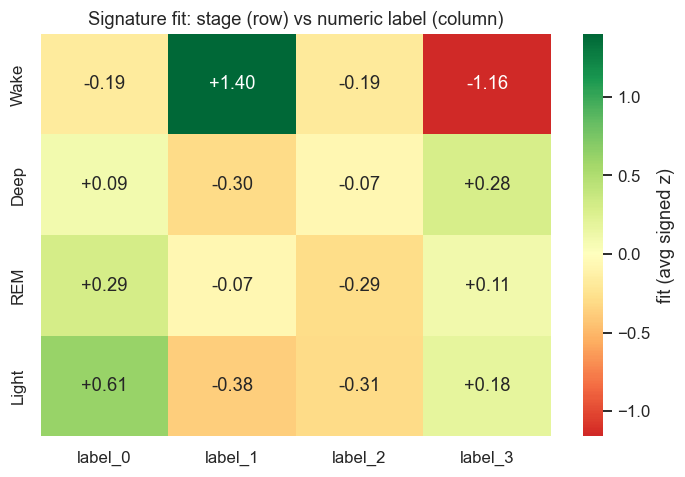

,label_0,label_1,label_2,label_3
Wake,-0.19,1.40,-0.19,-1.16
Deep,0.09,-0.30,-0.07,0.28
REM,0.29,-0.07,-0.29,0.11
Light,0.61,-0.38,-0.31,0.18


In [30]:
from scipy.optimize import linear_sum_assignment
from itertools import permutations

m = train.groupby(TARGET)[FEATURES].mean()        # rows = numeric label, z-units
labels = list(m.index)

sig = {
 "Wake":  [("body_movement_index", 1), ("emg_chin_tone", 1), ("eeg_alpha_power", 1),
           ("eeg_beta_power", 1), ("eeg_delta_power", -1), ("heart_rate_mean", 1)],
 "Deep":  [("eeg_delta_power", 3), ("eeg_slow_osc_power", 1), ("body_movement_index", -1),
           ("respiration_variability", -1), ("heart_rate_mean", -1), ("eeg_spectral_entropy", -1)],
 "REM":   [("eog_movement_density", 1), ("eog_amplitude", 1), ("eog_burst_index", 1),
           ("emg_chin_tone", -3), ("eeg_beta_power", 1), ("eeg_gamma_power", 1),
           ("heart_rate_variability", 1), ("respiration_variability", 1)],
 "Light": [("eeg_theta_power", 1), ("eeg_spindle_density", 1), ("eeg_kcomplex_rate", 1),
           ("body_movement_index", -1), ("emg_chin_tone", -1)],
}
stages = list(sig)

# normalised weighted score = average signed z per marker (comparable across stages)
S = np.zeros((4, 4))
for i, st in enumerate(stages):
    wsum = sum(abs(w) for _, w in sig[st])
    for j, lab in enumerate(labels):
        S[i, j] = sum(w * m.loc[lab, f] for f, w in sig[st]) / wsum

score_df = pd.DataFrame(S, index=stages, columns=[f"label_{l}" for l in labels])

r, c = linear_sum_assignment(-S)
mapping = {stages[i]: labels[j] for i, j in zip(r, c)}
print("OPTIMAL assignment:", mapping)
print("total fit:", round(S[r, c].sum(), 2))

plt.figure(figsize=(6.5, 4.5))
sns.heatmap(score_df, annot=True, fmt="+.2f", cmap="RdYlGn", center=0,
            cbar_kws={"label": "fit (avg signed z)"})
plt.title("Signature fit: stage (row) vs numeric label (column)")
plt.tight_layout(); plt.show()
score_df.round(2)

### 17b. How stable is the assignment?
If the top assignments are far apart, the mapping is trustworthy; if they're nearly tied,
it's a coin-flip.

In [31]:
perms = sorted(((sum(S[i, p[i]] for i in range(4)), p) for p in permutations(range(4))),
               reverse=True)
print("Top 3 assignments:")
for total, p in perms[:3]:
    print(f"  total {total:+.2f}:  " + ", ".join(f"{stages[i]}=label{labels[p[i]]}" for i in range(4)))

Top 3 assignments:
  total +2.05:  Wake=label1, Deep=label2, REM=label3, Light=label0
  total +2.01:  Wake=label1, Deep=label3, REM=label2, Light=label0
  total +1.80:  Wake=label1, Deep=label2, REM=label0, Light=label3


### 17c. Marker-by-marker check of the chosen mapping

In [32]:
for st in stages:
    lab = mapping[st]
    hits = sum(((m.loc[lab, f] > 0) == (w > 0)) for f, w in sig[st])
    print(f"\n{st} = label {lab}:  {hits}/{len(sig[st])} markers correct")
    for f, w in sig[st]:
        ok = (m.loc[lab, f] > 0) == (w > 0)
        print(f"   {'OK ' if ok else 'XX '} {f} ({'up' if w>0 else 'down'}) = {m.loc[lab, f]:+.2f}")


Wake = label 1:  6/6 markers correct
   OK  body_movement_index (up) = +0.33
   OK  emg_chin_tone (up) = +0.97
   OK  eeg_alpha_power (up) = +4.05
   OK  eeg_beta_power (up) = +1.05
   OK  eeg_delta_power (down) = -1.17
   OK  heart_rate_mean (up) = +0.85

Deep = label 2:  3/6 markers correct
   XX  eeg_delta_power (up) = -0.29
   OK  eeg_slow_osc_power (up) = +0.64
   OK  body_movement_index (down) = -0.27
   OK  respiration_variability (down) = -1.28
   XX  heart_rate_mean (down) = +0.64
   XX  eeg_spectral_entropy (down) = +1.28

REM = label 3:  3/8 markers correct
   XX  eog_movement_density (up) = -0.68
   XX  eog_amplitude (up) = -0.66
   XX  eog_burst_index (up) = -0.71
   OK  emg_chin_tone (down) = -1.50
   XX  eeg_beta_power (up) = -1.35
   XX  eeg_gamma_power (up) = -1.40
   OK  heart_rate_variability (up) = +1.18
   OK  respiration_variability (up) = +0.20

Light = label 0:  4/5 markers correct
   OK  eeg_theta_power (up) = +0.66
   OK  eeg_spindle_density (up) = +1.42
   O

### 17d. Verdict

| named stage | best numeric label | markers correct | confidence |
|---|---|---|---|
| **Wake**  | **label 1** | 6 / 6 | ★★★ certain |
| **Light** | **label 0** | 4 / 5 | ★★ strong |
| Deep  | label 2 | 3 / 6 | ★ weak |
| REM   | label 3 | 3 / 8 | ✗ poor |

**Two stages are now solid:**
- **Wake = label 1** — every marker agrees (alpha = 4.05, plus tone, movement, heart rate up; delta down).
- **Light = label 0** — theta, spindles **and** K-complexes all peak here. (Note: it's label **0**, not the
  cheat-sheet's "Stage 1" — your suspicion was right, the numbers don't line up.)

**Deep vs REM (labels 2 & 3) cannot be resolved:**
- **Label 3 carries BOTH hallmarks at once** — the highest delta (Deep's signature) *and* the strongest
  muscle atonia (REM's signature). Whichever stage it's assigned to, the other is left with **label 2,
  which has neither.** That's why Deep and REM both score badly.
- The **defining REM eye-movement markers** (`eog_movement_density`, `eog_amplitude`, `eog_burst_index`)
  are **low in both** labels 2 and 3 → REM has no clean home (same conclusion as §16).
- The top two assignments differ only by **swapping Deep/REM between labels 2 and 3** (+2.05 vs +2.01) —
  effectively a coin-flip. If you trust delta as Deep's hallmark, you'd flip to **Deep = 3, REM = 2**.

**Bottom line:** confidently **Wake = 1, Light = 0**; **Deep/REM = {2, 3} but unidentifiable**. And as
before — you don't need this mapping to compete; the model predicts the labels 0–3 directly.